# Lecture 20: Decision Trees & Random Forests

**F&W ECOL 458 — Environmental Data Science**

Reference: [scikit-learn Tree documentation](https://scikit-learn.org/stable/modules/tree.html) | [Random Forest](https://scikit-learn.org/stable/modules/ensemble.html#forest)

---

### Learning objectives

1. Explain how a decision tree makes predictions by recursively splitting features.
2. Define Gini impurity and information gain and describe how splits are chosen.
3. Identify overfitting in decision trees and apply pruning strategies.
4. Explain bagging and how random forests improve on individual trees.
5. Train decision trees and random forests in `scikit-learn` for both classification and regression.
6. Apply tree-based methods to predict shortwave radiation from atmospheric and surface variables.


## 1. From Linear Boundaries to Flexible Partitions

Every classifier and regressor we've seen so far has a notable limitation:

| Algorithm | What it struggles with |
|---|---|
| Linear / Logistic regression | Can only draw linear (straight-line) decision boundaries; can only fit straight lines to data |
| SVM (linear) | Same limitation as linear models |
| SVM (RBF) | Nonlinear, but very slow on large datasets ($O(N^2)$-$O(N^3)$); hard to interpret |
| Naive Bayes | Assumes features are independent of each other |
| KNN | Slow at prediction time (must compute distances to all training points); fails in high dimensions |

**Decision trees** address many of these issues simultaneously:

- They learn **nonlinear** decision boundaries and nonlinear regression surfaces naturally.
- They are **fast** to train and predict.
- They require **no feature scaling** (unlike SVM, KNN, and neural networks).
- They produce models that are **interpretable** — you can literally draw the decision logic as a flowchart that anyone can understand.
- They handle **both classification and regression** with the same framework.
- They naturally handle **mixed feature types** (continuous and categorical).

Perhaps most importantly, decision trees are the building blocks for **random forests** and **gradient-boosted trees (XGBoost)**, which are consistently among the top-performing ML methods in ecology, remote sensing, and environmental science.


## 2. The Intuition: Playing 20 Questions with Data

### The game

You've probably played "20 Questions" — one person thinks of something, and others try to guess it by asking yes-or-no questions. The strategy is to ask questions that **eliminate as many possibilities as quickly as possible**:

- "Is it alive?" — splits the universe roughly in half.
- "Is it bigger than a breadbox?" — another large split.
- "Does it have fur?" — narrows it further.

A good player asks the most *informative* question at each step — the one that divides the remaining possibilities most evenly.

### A decision tree does exactly this

At each step, a decision tree asks the single yes-or-no question about one feature that **best separates** the data. It keeps asking questions — splitting the data at each step — until it reaches a final answer.

### Ecological example: Classifying a satellite pixel

Suppose we want to classify a pixel as **Forest**, **Water**, or **Urban** based on its spectral values:

```
Is NDVI > 0.4?
|
+-- Yes: Is NIR > 3000?
|        |
|        +-- Yes --> FOREST
|        +-- No  --> AGRICULTURE
|
+-- No:  Is Blue > 1000?
         |
         +-- Yes --> URBAN
         +-- No  --> WATER
```

Each internal node asks a question about **one feature** and **one threshold**. Each leaf node gives a prediction. The path from root to leaf is the complete decision rule — and it's easy to explain to anyone.

### Regression example: Predicting shortwave radiation

The same tree structure works for predicting a continuous value:

```
Is SZA > 75 degrees?
|
+-- Yes: Is Cloud Fraction > 0.5?
|        |
|        +-- Yes --> SW = 50 W/m2  (sun is low + cloudy)
|        +-- No  --> SW = 120 W/m2 (sun is low but clear)
|
+-- No:  Is AOD > 0.3?
         |
         +-- Yes --> SW = 400 W/m2 (high sun but hazy)
         +-- No  --> SW = 600 W/m2 (high sun, clear sky)
```

Instead of predicting a class at each leaf, the tree predicts the **average target value** of the training samples that landed in that leaf. This is called a **regression tree**.


## 3. How Does the Tree Choose Its Questions?

At each node, the tree algorithm considers **every possible split on every feature** — every feature, and every threshold value — and picks the one that produces the **most improvement**. But how do we measure "improvement"?

### For classification: Gini Impurity

The most common measure of node purity is **Gini impurity**:

$$
G = 1 - \sum_{c=1}^{C} p_c^2
$$

where $p_c$ is the proportion of class $c$ in a node, and $C$ is the total number of classes.

**How to interpret Gini impurity:**

- $G = 0$: the node is **perfectly pure** — every sample belongs to the same class. This is the best possible outcome. For example, if all 100 samples in a node are "Forest," then $G = 1 - 1^2 = 0$.

- $G = 0.5$ (for 2 classes): **maximum impurity** — the classes are equally mixed. For example, 50 Forest and 50 Water: $G = 1 - (0.5^2 + 0.5^2) = 0.5$. This is the worst case — the node tells us nothing about the class.

- For $C$ classes, maximum impurity is $G = 1 - 1/C$ (all classes equally represented).

The tree's goal is to make each child node as pure as possible — it picks the split that produces the **largest decrease in Gini impurity**. This decrease is called **information gain**.

### Worked example

Suppose a node has 100 samples: 60 Forest, 40 Water. The Gini impurity before splitting is:

$$
G_{\text{parent}} = 1 - (0.6^2 + 0.4^2) = 1 - (0.36 + 0.16) = 0.48
$$

Now consider a candidate split: "NDVI > 0.4":
- **Left child** (NDVI > 0.4): 58 Forest, 5 Water (63 total)
  $G_L = 1 - (58/63)^2 - (5/63)^2 = 1 - 0.847 - 0.006 = 0.147$
- **Right child** (NDVI <= 0.4): 2 Forest, 35 Water (37 total)
  $G_R = 1 - (2/37)^2 - (35/37)^2 = 1 - 0.003 - 0.895 = 0.102$

The weighted average Gini after splitting:

$$
G_{\text{split}} = \frac{63}{100} \times 0.147 + \frac{37}{100} \times 0.102 = 0.093 + 0.038 = 0.131
$$

**Information gain** = $G_{\text{parent}} - G_{\text{split}} = 0.48 - 0.131 = 0.349$

That's a large improvement! This split effectively separates most Forest pixels (high NDVI) from most Water pixels (low NDVI).

The tree evaluates every possible split on every feature and picks the one with the **highest information gain**. Then it repeats the process for each child node, recursively, until some stopping criterion is met.

### For regression: Variance reduction

For regression trees, the concept is the same but the metric changes. Instead of Gini impurity, the tree minimizes **variance** (or equivalently, mean squared error) within each node.

At each split, the tree picks the threshold that **minimizes the total weighted variance** of the target values in the two child nodes. Intuitively, it groups together training samples that have similar target values.


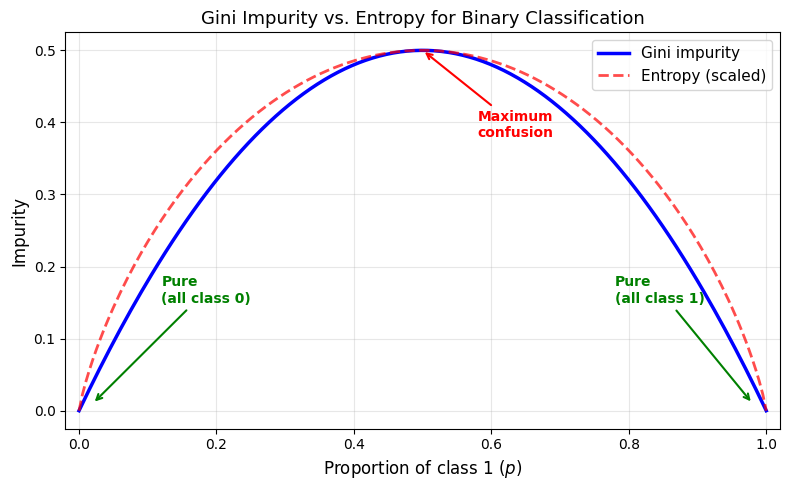

Gini impurity examples:
  All class A (p=1.0):     G = 0.00  (pure)
  90% A, 10% B (p=0.9):   G = 0.18
  70% A, 30% B (p=0.7):   G = 0.42
  50% A, 50% B (p=0.5):   G = 0.50  (max impurity)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Visualize Gini impurity for binary classification ──
p = np.linspace(0, 1, 200)
gini = 1 - p**2 - (1-p)**2
entropy = -p * np.log2(np.clip(p, 1e-10, 1)) - (1-p) * np.log2(np.clip(1-p, 1e-10, 1))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p, gini, 'b-', linewidth=2.5, label='Gini impurity')
ax.plot(p, entropy / 2, 'r--', linewidth=2, label='Entropy (scaled)', alpha=0.7)

ax.set_xlabel('Proportion of class 1 ($p$)', fontsize=12)
ax.set_ylabel('Impurity', fontsize=12)
ax.set_title('Gini Impurity vs. Entropy for Binary Classification', fontsize=13)

# Annotations
ax.annotate('Pure\n(all class 0)', xy=(0.02, 0.01), fontsize=10,
            xytext=(0.12, 0.15), arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
            color='green', fontweight='bold')
ax.annotate('Pure\n(all class 1)', xy=(0.98, 0.01), fontsize=10,
            xytext=(0.78, 0.15), arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
            color='green', fontweight='bold')
ax.annotate('Maximum\nconfusion', xy=(0.5, 0.5), fontsize=10,
            xytext=(0.58, 0.38), arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            color='red', fontweight='bold')

ax.legend(fontsize=11)
ax.set_xlim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Gini impurity examples:")
print(f"  All class A (p=1.0):     G = {1 - 1**2 - 0**2:.2f}  (pure)")
print(f"  90% A, 10% B (p=0.9):   G = {1 - 0.9**2 - 0.1**2:.2f}")
print(f"  70% A, 30% B (p=0.7):   G = {1 - 0.7**2 - 0.3**2:.2f}")
print(f"  50% A, 50% B (p=0.5):   G = {1 - 0.5**2 - 0.5**2:.2f}  (max impurity)")


The plot shows both Gini impurity and entropy (another common split criterion, used with `criterion='entropy'` in sklearn). They are nearly identical in shape — both are zero at the extremes (pure nodes) and maximum at 50/50. Gini is slightly faster to compute, which is why it's the default in scikit-learn.

> **Entropy** uses the formula $H = -\sum p_c \log_2(p_c)$ and is rooted in information theory. The resulting split criterion is called **information gain** (decrease in entropy). In practice, Gini and entropy give very similar trees.


## 4. Decision Trees in `scikit-learn`: Classification

Let's train a decision tree on the Iris dataset and visualize its structure.


In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ── Train an unrestricted decision tree ──
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
print(f"Training accuracy: {tree.score(X_train, y_train):.2%}")
print(f"Test accuracy:     {metrics.accuracy_score(y_test, y_pred):.2%}")
print(f"Tree depth:        {tree.get_depth()}")
print(f"Number of leaves:  {tree.get_n_leaves()}")


Training accuracy: 100.00%
Test accuracy:     100.00%
Tree depth:        6
Number of leaves:  10


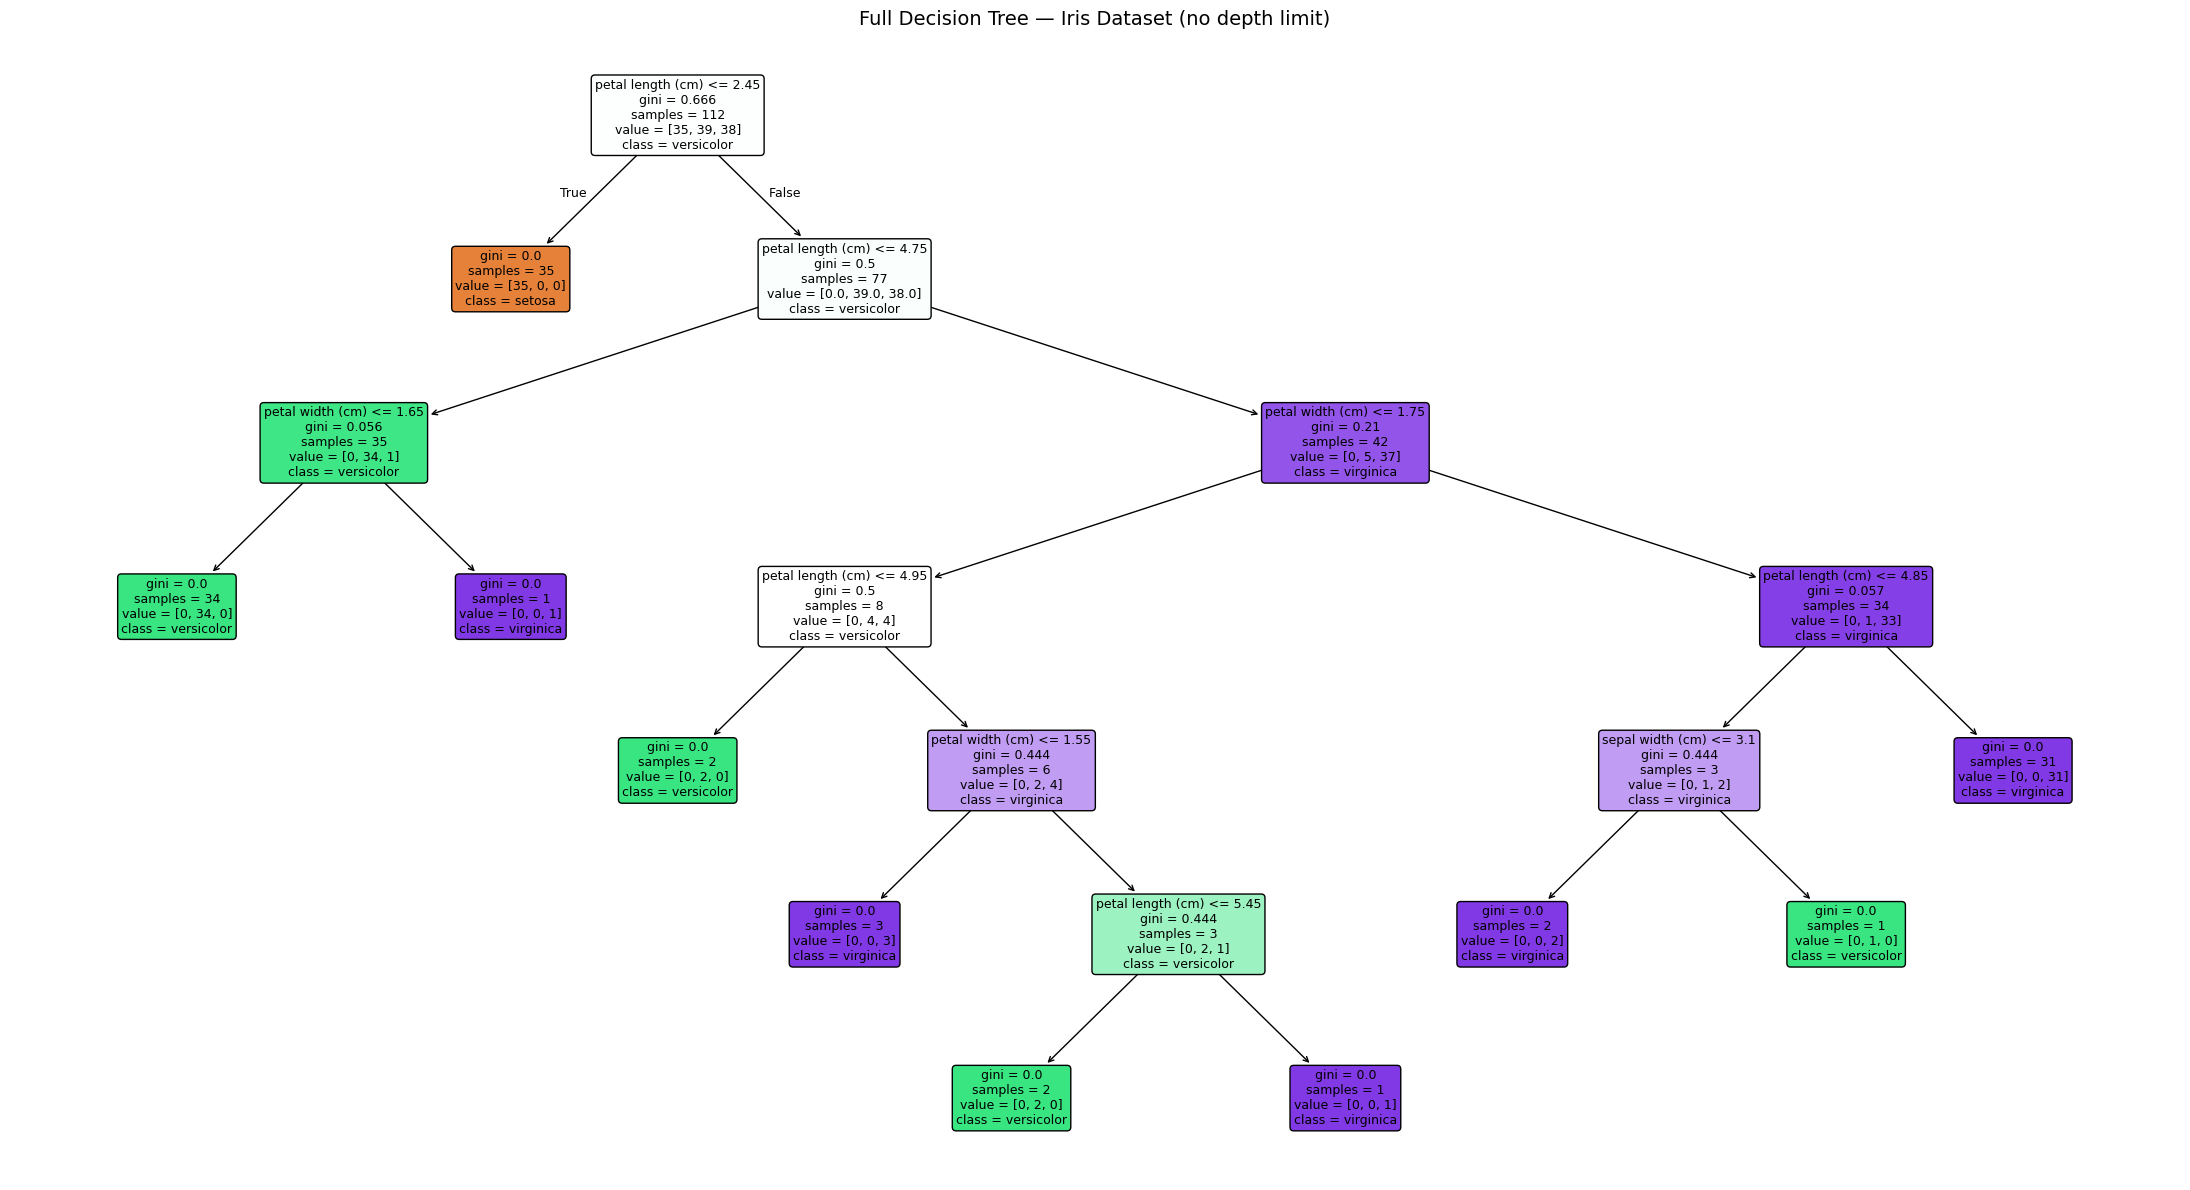

In [ ]:
# ── Visualize the full tree ──
fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(tree, filled=True, feature_names=iris.feature_names,
          class_names=iris.target_names, rounded=True, fontsize=9, ax=ax)
ax.set_title("Full Decision Tree — Iris Dataset (no depth limit)", fontsize=14)
plt.tight_layout()
plt.show()


### Reading the tree visualization

Each box (node) in the tree shows 5 pieces of information:

1. **Split condition** (e.g., "petal width (cm) <= 0.8") — the yes/no question. Left branch = True, Right branch = False.
2. **Gini impurity** — how mixed the classes are at this node. Lower is purer.
3. **Samples** — how many training examples reached this node.
4. **Value** — the class distribution, e.g., [37, 0, 0] means 37 setosa, 0 versicolor, 0 virginica.
5. **Class** — the majority class (the prediction if this were a leaf).

The **color intensity** reflects purity: deeper orange/purple/green means the node is dominated by one class; white means a mixed node.

**Reading a decision path:** To classify a new flower, start at the root node (top) and follow the yes/no branches down. For example:
- "petal width <= 0.8?" → Yes → classify as **setosa** (done in one question!)
- "petal width <= 0.8?" → No → "petal width <= 1.75?" → Yes → probably **versicolor**
- etc.

Notice that the very first split uses **petal width** — this is the single most informative feature for separating Iris species. The tree discovered this automatically from the data.

Also notice that the tree is quite deep and has many leaves. Training accuracy is 100% — the tree perfectly memorizes every training example. This is a sign of potential **overfitting**.


## 5. Overfitting and Pruning

### The problem

An unrestricted decision tree will keep splitting until every leaf is pure — perfectly classifying every single training point. This sounds great, but it means the tree has **memorized** the training data, including all its noise, measurement errors, and idiosyncrasies.

Consider this: if one training pixel has an unusual spectral signature due to a sensor glitch, an unpruned tree will create a special branch just for that one pixel. When it encounters a new pixel, that branch adds no value — it's noise, not signal.

The result: high training accuracy but significantly lower test accuracy. This gap is the hallmark of overfitting.

### The solution: control tree complexity

`scikit-learn` provides several parameters to limit tree growth. These are called **pre-pruning** strategies because they stop the tree from growing too large in the first place:

| Parameter | What it does | Typical values |
|---|---|---|
| `max_depth` | Limits the maximum depth (number of levels) of the tree | 3–15 |
| `min_samples_split` | A node must have at least this many samples to be split further | 2–20 |
| `min_samples_leaf` | Each leaf node must have at least this many samples | 1–10 |
| `max_leaf_nodes` | Limits the total number of leaf nodes | 10–100 |

The most commonly used is `max_depth`. Let's see how it affects performance.


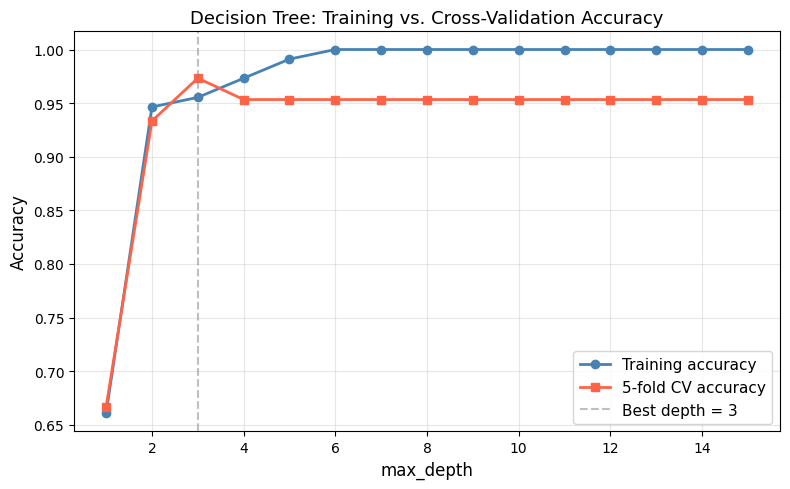

Best max_depth by CV: 3
CV accuracy at best depth: 0.973
Training accuracy at best depth: 0.955


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# ── Sweep max_depth and compare training vs. CV accuracy ──
depths = list(range(1, 16))
train_scores = []
cv_scores = []

for d in depths:
    tree_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree_d.fit(X_train, y_train)
    train_scores.append(tree_d.score(X_train, y_train))
    cv_scores.append(cross_val_score(tree_d, X, y, cv=5).mean())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, train_scores, 'o-', linewidth=2, label='Training accuracy', color='steelblue')
ax.plot(depths, cv_scores, 's-', linewidth=2, label='5-fold CV accuracy', color='tomato')
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision Tree: Training vs. Cross-Validation Accuracy', fontsize=13)
ax.legend(fontsize=11)

best_depth = depths[np.argmax(cv_scores)]
ax.axvline(best_depth, color='gray', linestyle='--', alpha=0.5,
           label=f'Best depth = {best_depth}')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best max_depth by CV: {best_depth}")
print(f"CV accuracy at best depth: {max(cv_scores):.3f}")
print(f"Training accuracy at best depth: {train_scores[best_depth-1]:.3f}")


The pattern is clear:

- At **low depth (1-2)**, both training and CV accuracy are low — the tree is too simple (**underfitting**).
- At **moderate depth (3-5)**, CV accuracy peaks — the tree captures the real patterns without memorizing noise.
- At **high depth (10+)**, training accuracy hits 100% but CV accuracy plateaus or drops — the tree is memorizing noise (**overfitting**).

The widening gap between training and CV accuracy at high depth is the classic overfitting signature.


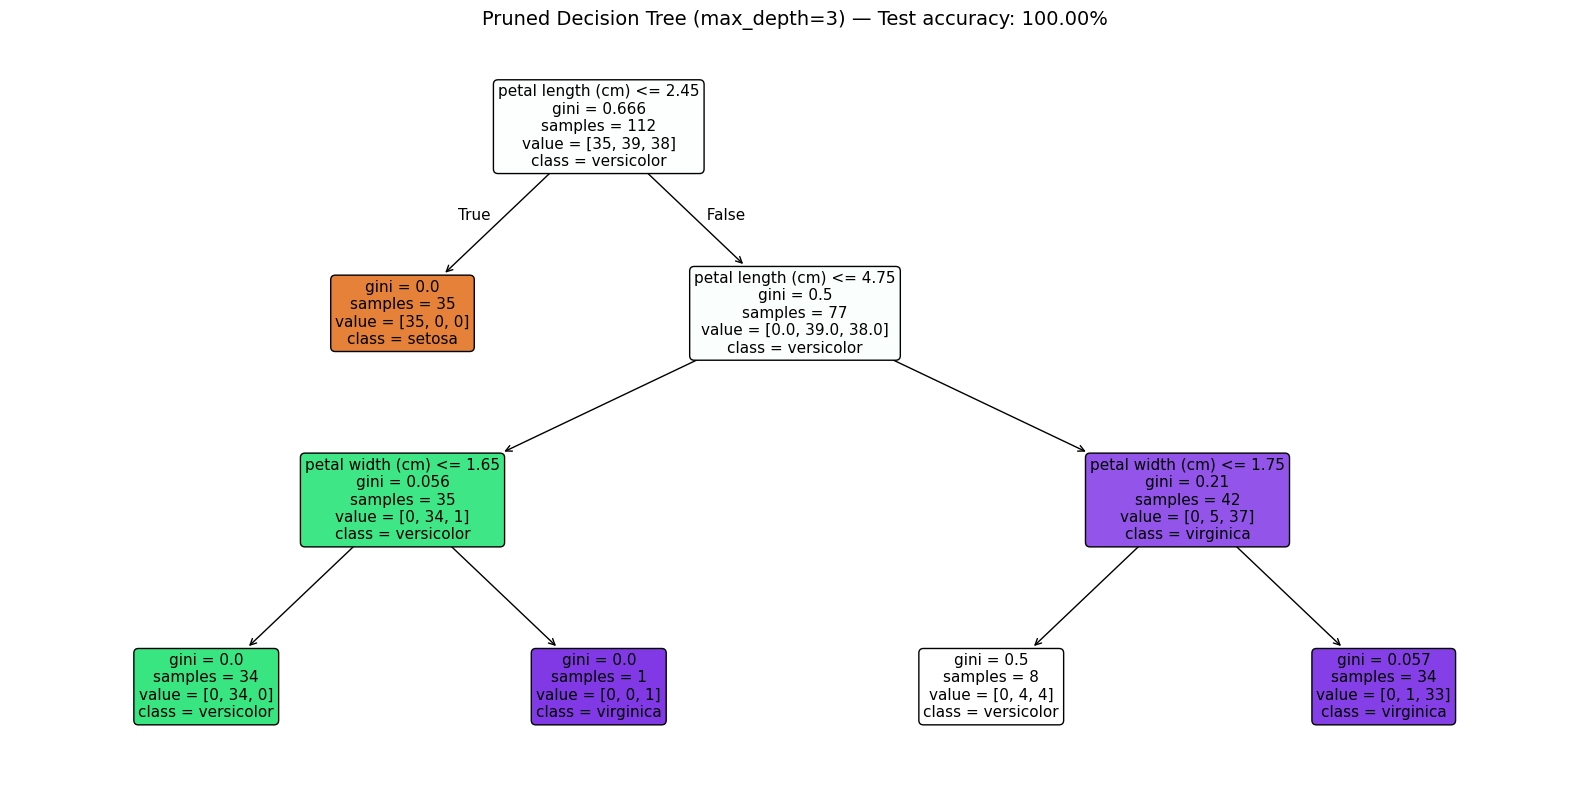

In [ ]:
# ── Visualize a pruned, interpretable tree ──
tree_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_pruned.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree_pruned, filled=True, feature_names=iris.feature_names,
          class_names=iris.target_names, rounded=True, fontsize=11, ax=ax)
ax.set_title(f"Pruned Decision Tree (max_depth=3) — Test accuracy: {tree_pruned.score(X_test, y_test):.2%}",
             fontsize=14)
plt.tight_layout()
plt.show()


This pruned tree is only 3 levels deep — much simpler than the full tree — yet it achieves nearly the same test accuracy. It uses only 2–3 features and is easy to interpret.

> **Key principle:** Prefer the simplest model that achieves competitive accuracy. A shallow tree that's easy to understand and explains 95% of the variance is usually better than a deep tree that memorizes 100% of the training data but generalizes poorly.


## 6. Visualizing Decision Boundaries

Decision trees partition feature space into **rectangular regions** — because each split is a threshold on a single feature, creating a vertical or horizontal cut. Let's see what these boundaries look like for different data shapes:


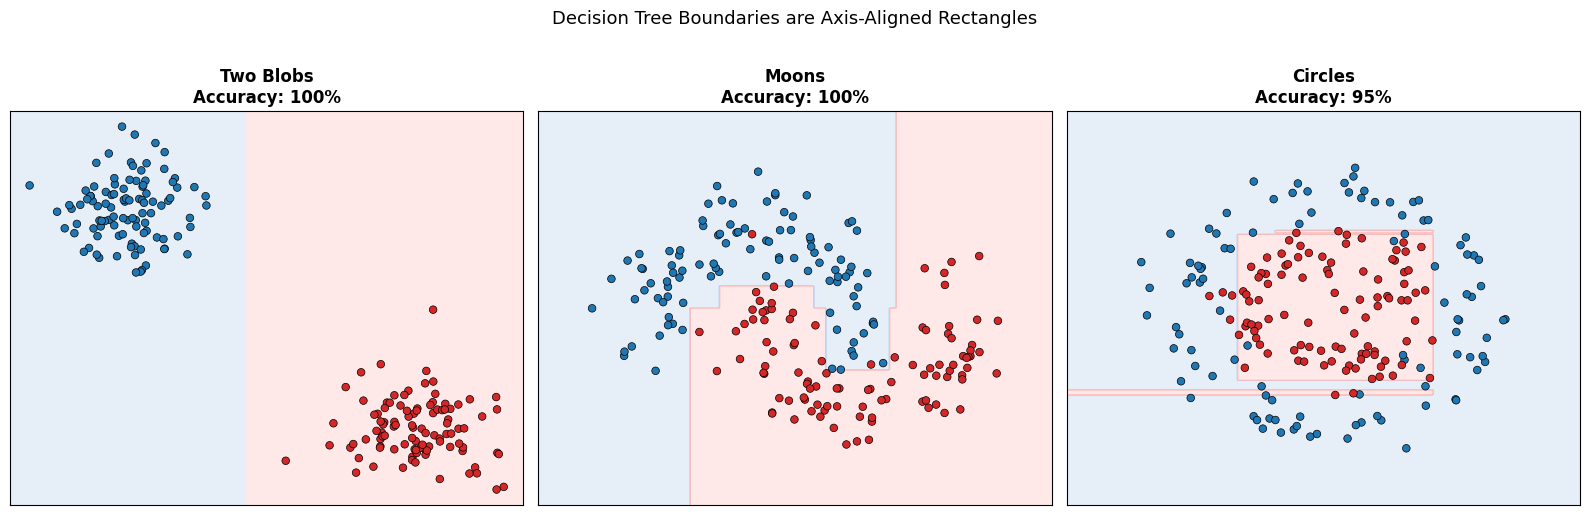

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons, make_circles, make_blobs
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

datasets = [
    ("Two Blobs", make_blobs(n_samples=200, centers=2, cluster_std=1.0, random_state=42)),
    ("Moons", make_moons(n_samples=200, noise=0.2, random_state=42)),
    ("Circles", make_circles(n_samples=200, factor=0.5, noise=0.15, random_state=42)),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmap_bg = ListedColormap(["#AEC7E8", "#FFB3B3"])
cmap_pts = ListedColormap(["#1f77b4", "#d62728"])

for ax, (name, (X_ds, y_ds)) in zip(axes, datasets):
    tree_ds = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_ds, y_ds)

    x_min, x_max = X_ds[:, 0].min() - 0.5, X_ds[:, 0].max() + 0.5
    y_min, y_max = X_ds[:, 1].min() - 0.5, X_ds[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    Z = tree_ds.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    ax.scatter(X_ds[:, 0], X_ds[:, 1], c=y_ds, cmap=cmap_pts,
               edgecolors='k', s=30, linewidths=0.5)
    ax.set_title(f'{name}\nAccuracy: {tree_ds.score(X_ds, y_ds):.0%}', fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Decision Tree Boundaries are Axis-Aligned Rectangles', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Notice the **staircase pattern** — every boundary is parallel to one of the axes (horizontal or vertical cuts). Decision trees cannot draw diagonal or curved lines directly. Instead, they approximate curves with many small rectangular steps.

This means:
- For **blobs** (linearly separable): the tree finds a clean boundary in very few splits.
- For **moons** and **circles**: the tree can still classify well, but it needs many more splits — each adding a small rectangular cut to approximate the curved boundary.

Compare this to SVM (smooth curves) or KNN (irregular boundaries). Trees trade boundary smoothness for interpretability and speed.


## 7. From One Tree to a Forest: Random Forests

### The problem with a single tree

A single decision tree has a critical weakness: **high variance**. Small changes in the training data — adding or removing just a few samples — can completely change the tree structure. A different random split of train/test data might produce a tree with different features, different thresholds, and different predictions. This instability is a symptom of overfitting.

### The Wisdom of Crowds

Here's an analogy. If you ask **one person** to estimate the number of jelly beans in a jar, they might be wildly off — maybe too high, maybe too low. But if you ask **100 people** and take the **average** of their estimates, something remarkable happens: the average is usually very close to the true number. Individual errors — some too high, some too low — cancel out.

This phenomenon is called the **wisdom of crowds**, and it's the core principle behind **random forests**.

### How random forests work

A random forest trains **many decision trees** (typically 100–500) and combines their predictions. The trees are made diverse through two forms of randomness:

**1. Bootstrap sampling (Bagging)**

Each tree is trained on a **bootstrap sample** — a random subset of the training data, drawn *with replacement*. "With replacement" means some training points appear multiple times and others are left out entirely. Each tree sees a slightly different version of the data.

The name "bagging" stands for **B**ootstrap **AGG**regat**ING**.

**2. Random feature subsets**

At each split in each tree, instead of considering all features, the algorithm randomly selects a **subset of features** (typically $\sqrt{M}$ features for classification, $M/3$ for regression, where $M$ is the total number of features). The split is chosen from this subset only.

This forces the trees to be **diverse**. Without this, if one feature (say, NDVI) is very strong, every tree would split on it first, and all trees would look similar — defeating the purpose of the ensemble.

**3. Aggregation**

For classification, each tree "votes" for a class, and the **majority vote** wins. For regression, the predictions are **averaged**.

### Why does this work?

Each individual tree is a noisy, potentially overfit estimator. But because the trees are trained on different data subsets and use different feature subsets, their errors are **uncorrelated**. When you average many uncorrelated noisy estimates, the noise cancels out and the signal remains.

Mathematically: the variance of the average of $n$ independent estimators is $1/n$ times the variance of a single estimator. So 100 trees have ~100x lower variance than 1 tree, while the bias stays roughly the same.

This is why random forests are so robust — they rarely overfit severely, even without careful hyperparameter tuning.


## 8. Random Forests in `scikit-learn`


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics
import numpy as np

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# ── Train Random Forest ──
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"Random Forest accuracy:  {metrics.accuracy_score(y_test, y_pred):.2%}")
print(f"Number of trees:         {rf.n_estimators}")

# ── Compare to a single tree ──
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
print(f"Single tree accuracy:    {tree.score(X_test, y_test):.2%}")

# ── Cross-validation comparison ──
print(f"\n5-fold Cross-Validation:")
for name, clf in [("Single tree", DecisionTreeClassifier(random_state=42)),
                  ("RF (100 trees)", RandomForestClassifier(100, random_state=42)),
                  ("RF (500 trees)", RandomForestClassifier(500, random_state=42))]:
    scores = cross_val_score(clf, X, y, cv=5)
    print(f"  {name:20s}: {scores.mean():.3f} +/- {scores.std():.3f}")


Random Forest accuracy:  100.00%
Number of trees:         100
Single tree accuracy:    100.00%

5-fold Cross-Validation:
  Single tree         : 0.953 +/- 0.034
  RF (100 trees)      : 0.967 +/- 0.021
  RF (500 trees)      : 0.967 +/- 0.021


The random forest consistently outperforms the single decision tree, and the improvement comes with almost no additional complexity from the user's perspective — the only new parameter is `n_estimators` (number of trees).

> **How many trees?** Accuracy generally improves rapidly from 1 to ~100 trees, then plateaus. Going from 100 to 500 trees adds very little accuracy but doubles the compute time. 100–200 trees is a good default for most datasets.


### Benchmark: Covertype Dataset

Let's compare decision trees, random forests, and the other classifiers we've covered on a larger, more realistic dataset.


In [ ]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import time

covtype = fetch_covtype()
rng = np.random.RandomState(42)
idx = rng.choice(len(covtype.data), size=10000, replace=False)
X_sub, y_sub = covtype.data[idx], covtype.target[idx]

X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.25, random_state=42, stratify=y_sub
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

classifiers = {
    "Decision Tree":     (DecisionTreeClassifier(max_depth=15, random_state=42), X_train, X_test),
    "Random Forest":     (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), X_train, X_test),
    "SVM (RBF)":         (SVC(kernel="rbf"), X_train_sc, X_test_sc),
    "KNN (k=5)":         (KNeighborsClassifier(n_neighbors=5), X_train_sc, X_test_sc),
    "Gaussian NB":       (GaussianNB(), X_train_sc, X_test_sc),
}

print(f"Dataset: Covertype (N={len(X_sub)}, M={X_sub.shape[1]}, 7 classes)")
print(f"\n{'Classifier':<20s}  {'Train (s)':>10s}  {'Accuracy':>10s}  {'Scaling':>10s}")
print("-" * 55)

for name, (clf, Xtr, Xte) in classifiers.items():
    t0 = time.time()
    clf.fit(Xtr, y_train)
    t_train = time.time() - t0
    acc = accuracy_score(y_test, clf.predict(Xte))
    scaling = "No" if name in ["Decision Tree", "Random Forest"] else "Yes"
    print(f"{name:<20s}  {t_train:>10.3f}  {acc:>10.2%}  {scaling:>10s}")


Dataset: Covertype (N=10000, M=54, 7 classes)

Classifier             Train (s)    Accuracy     Scaling
-------------------------------------------------------
Decision Tree              0.113      73.00%          No
Random Forest              1.561      80.72%          No
SVM (RBF)                  2.858      74.08%         Yes
KNN (k=5)                  0.002      74.76%         Yes
Gaussian NB                0.009      14.12%         Yes


Random forests dominate this comparison:

- **Highest accuracy** — the ensemble captures complex, nonlinear interactions among the 54 features.
- **No feature scaling required** — trees split on individual feature thresholds, not on distances. You can feed raw data directly.
- **Fast, parallelizable training** — set `n_jobs=-1` to use all CPU cores.
- **Handles high dimensions** — 54 features is no problem; irrelevant features automatically get low importance.

This is why random forests have become the default go-to method for most ecological and remote sensing classification tasks.


## 9. Feature Importance

One of the most valuable outputs of tree-based models is **feature importance** — a ranking of which features contribute most to predictions.

### How Gini importance works

For each feature, the algorithm sums the **total reduction in Gini impurity** (for classification) or **variance** (for regression) across all splits that use that feature, across all trees in the forest. Features chosen frequently for high-quality splits get high importance.

The importances are normalized to sum to 1.0.

This is incredibly useful for ecological research — it tells you which environmental variables actually matter for your prediction, and which ones you could remove without losing performance.


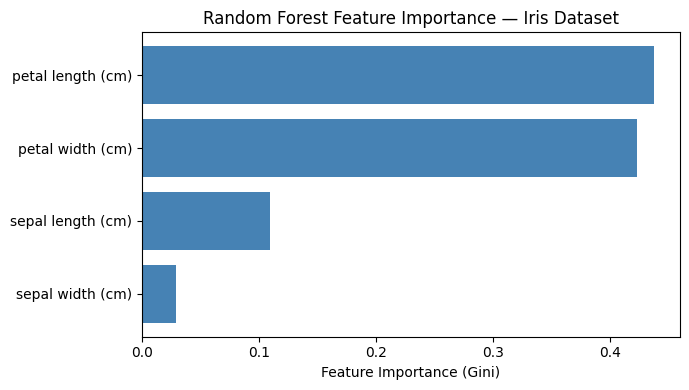

  petal length (cm)        : 0.438
  petal width (cm)         : 0.423
  sepal length (cm)        : 0.110
  sepal width (cm)         : 0.030


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Feature importance from Iris Random Forest ──
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(range(len(sorted_idx)), importances[sorted_idx], color='steelblue')
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels(np.array(iris.feature_names)[sorted_idx])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest Feature Importance — Iris Dataset')
plt.tight_layout()
plt.show()

for name, imp in sorted(zip(iris.feature_names, importances), key=lambda x: -x[1]):
    print(f"  {name:25s}: {imp:.3f}")


**Petal width** and **petal length** dominate — consistent with what we found from PCA biplots (Lecture 19) and the decision tree visualizations above (the first split is always on petal width).

Sepal features contribute much less. This tells us: if you only had time to measure two things about an iris flower, measure the petals.

We'll dive deeper into feature importance — including permutation importance and SHAP values — in the next lecture on XGBoost.


## 10. Application: Predicting Shortwave Radiation with Tree-Based Regression

Let's apply decision trees and random forests to a **real environmental regression problem**: predicting incoming shortwave (SW) radiation at the Earth's surface from atmospheric and surface variables.

### The dataset: SW.csv

The dataset contains the following variables:

| Variable | Full name | Unit | Role |
|---|---|---|---|
| **SZA** | Solar Zenith Angle | degrees | Feature — angle of the sun; higher = sun lower in sky |
| **AOD** | Aerosol Optical Depth | unitless | Feature — atmospheric aerosol loading; higher = hazier |
| **COD** | Cloud Optical Depth | unitless | Feature — cloud thickness; higher = thicker clouds |
| **CLD_FRAC** | Cloud Fraction | 0–1 | Feature — fraction of sky covered by clouds |
| **UW** | Water Column | cm | Feature — total precipitable water in the atmosphere |
| **TO3** | Total Ozone | DU | Feature — total column ozone |
| **Pressure** | Air Pressure | hPa | Feature — surface air pressure |
| **BSA** | Black-Sky Albedo | 0–1 | Feature — surface albedo under direct-beam illumination |
| **WSA** | White-Sky Albedo | 0–1 | Feature — surface albedo under diffuse illumination |
| **SW_direct** | Direct Shortwave Radiation | W/m$^2$ | Target — radiation arriving directly from the sun |
| **SW_diffuse** | Diffuse Shortwave Radiation | W/m$^2$ | Target — radiation scattered by atmosphere/clouds |

We want to predict **SW_direct**, **SW_diffuse**, and their sum **SW = SW_direct + SW_diffuse** (total downwelling shortwave radiation at the surface).

### Why this matters

Shortwave radiation drives photosynthesis, evapotranspiration, snowmelt, and the surface energy balance. Accurate SW estimates are essential for ecosystem models (e.g., IBIS, CLM), agricultural yield forecasts, and solar energy planning. Radiative transfer models (e.g., RRTM, DISORT) compute SW from atmospheric state variables, but they are computationally expensive. A fast ML emulator could approximate the same results in a fraction of the time.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load the dataset ──
# Adjust the path to where your SW.csv file is located
# For Colab with Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/path/to/SW.csv')

# For demonstration, we generate synthetic data matching the expected structure
# Replace this block with: df = pd.read_csv('SW.csv') when using real data
np.random.seed(42)
n = 5000

SZA = np.random.uniform(0, 85, n)
AOD = np.random.exponential(0.15, n)
COD = np.random.exponential(5, n)
CLD_FRAC = np.random.uniform(0, 1, n)
UW = np.random.uniform(0.5, 5, n)
TO3 = np.random.uniform(250, 450, n)
Pressure = np.random.uniform(850, 1050, n)
BSA = np.random.uniform(0.05, 0.4, n)
WSA = np.random.uniform(0.05, 0.4, n)

# Physically-motivated synthetic targets
cos_sza = np.cos(np.radians(SZA))
SW_direct = np.maximum(0, 1361 * cos_sza * np.exp(-AOD / cos_sza) * (1 - CLD_FRAC * 0.9)
                       + np.random.normal(0, 15, n))
SW_diffuse = np.maximum(0, 200 * cos_sza * (0.3 + 0.5 * CLD_FRAC + 0.3 * AOD)
                        + np.random.normal(0, 10, n))

df = pd.DataFrame({
    'SZA': SZA, 'AOD': AOD, 'COD': COD, 'CLD_FRAC': CLD_FRAC,
    'UW': UW, 'TO3': TO3, 'Pressure': Pressure, 'BSA': BSA, 'WSA': WSA,
    'SW_direct': SW_direct, 'SW_diffuse': SW_diffuse
})
df['SW'] = df['SW_direct'] + df['SW_diffuse']

print(f"Dataset shape: {df.shape}")
print(f"\nFeature statistics:")
print(df.describe().round(2))


Dataset shape: (5000, 12)

Feature statistics:
           SZA      AOD      COD  CLD_FRAC       UW      TO3  Pressure  \
count  5000.00  5000.00  5000.00   5000.00  5000.00  5000.00   5000.00   
mean     42.23     0.14     5.06      0.51     2.79   348.26    950.12   
std      24.62     0.14     5.08      0.29     1.30    56.91     57.67   
min       0.00     0.00     0.00      0.00     0.50   250.02    850.00   
25%      20.73     0.04     1.42      0.26     1.67   299.43    899.50   
50%      42.50     0.10     3.43      0.51     2.81   348.20    950.38   
75%      63.59     0.20     7.15      0.75     3.91   396.43    999.65   
max      84.98     1.14    42.72      1.00     5.00   449.95   1049.96   

           BSA      WSA  SW_direct  SW_diffuse       SW  
count  5000.00  5000.00    5000.00     5000.00  5000.00  
mean      0.22     0.22     416.58       80.55   497.13  
std       0.10     0.10     307.09       41.15   314.92  
min       0.05     0.05       0.00        0.00     0.5

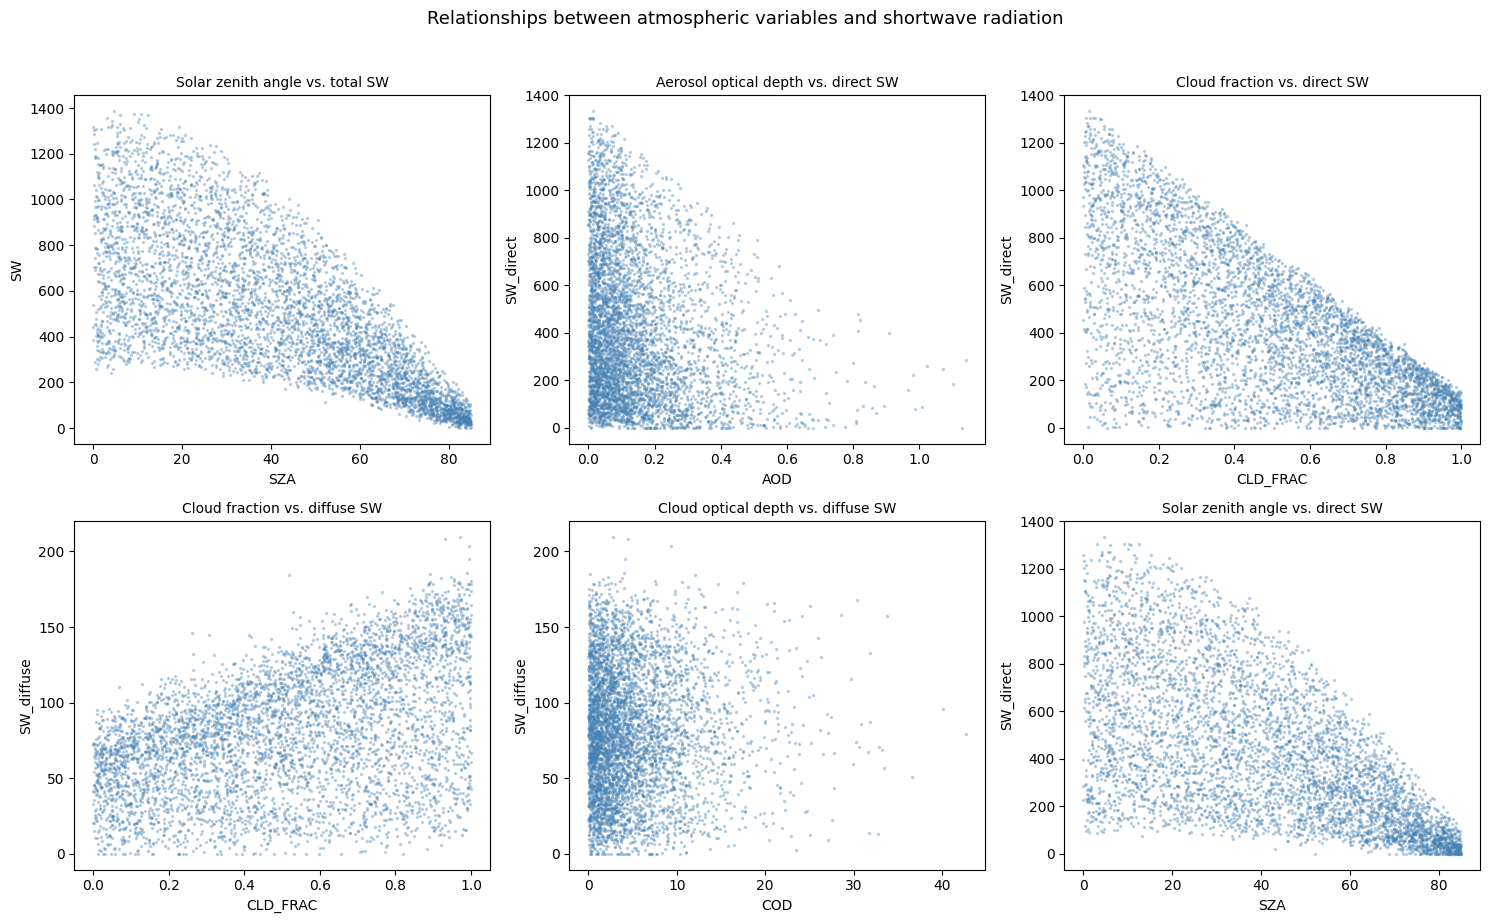

In [ ]:
# ── Explore the data: distributions and correlations ──
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Key relationships
pairs = [
    ('SZA', 'SW', 'Solar zenith angle vs. total SW'),
    ('AOD', 'SW_direct', 'Aerosol optical depth vs. direct SW'),
    ('CLD_FRAC', 'SW_direct', 'Cloud fraction vs. direct SW'),
    ('CLD_FRAC', 'SW_diffuse', 'Cloud fraction vs. diffuse SW'),
    ('COD', 'SW_diffuse', 'Cloud optical depth vs. diffuse SW'),
    ('SZA', 'SW_direct', 'Solar zenith angle vs. direct SW'),
]

for ax, (xvar, yvar, title) in zip(axes.flat, pairs):
    ax.scatter(df[xvar], df[yvar], s=2, alpha=0.3, color='steelblue')
    ax.set_xlabel(xvar, fontsize=10)
    ax.set_ylabel(yvar, fontsize=10)
    ax.set_title(title, fontsize=10)

plt.suptitle('Relationships between atmospheric variables and shortwave radiation',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


These scatter plots reveal the physics:

- **SZA vs. SW:** Strong nonlinear relationship. As the sun gets lower (higher SZA), total SW drops dramatically. The relationship follows a cosine curve.
- **AOD vs. SW_direct:** More aerosols attenuate direct-beam radiation. The relationship is exponential (Beer-Lambert law).
- **CLD_FRAC vs. SW_direct:** More clouds block direct sunlight — strong negative relationship.
- **CLD_FRAC vs. SW_diffuse:** More clouds *increase* diffuse radiation (up to a point) because clouds scatter sunlight in all directions.
- **COD vs. SW_diffuse:** Thicker clouds scatter more, increasing diffuse radiation initially, then blocking all radiation when extremely thick.

These are all **nonlinear** relationships — exactly where tree-based methods should excel over linear regression.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import time

# ── Prepare features and targets ──
feature_cols = ['SZA', 'AOD', 'COD', 'CLD_FRAC', 'UW', 'TO3', 'Pressure', 'BSA', 'WSA']
target_cols = ['SW_direct', 'SW_diffuse', 'SW']

X = df[feature_cols].values
y_direct = df['SW_direct'].values
y_diffuse = df['SW_diffuse'].values
y_total = df['SW'].values

X_train, X_test, yd_train, yd_test, yf_train, yf_test, yt_train, yt_test = (
    train_test_split(X, y_direct, y_diffuse, y_total,
                     test_size=0.25, random_state=42)
)

# ── Train models for total SW ──
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree (depth=10)': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Decision Tree (unlimited)': DecisionTreeRegressor(random_state=42),
    'Random Forest (100 trees)': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

print("=== Predicting Total Shortwave Radiation (SW = SW_direct + SW_diffuse) ===")
print(f"{'Model':<30s}  {'Train R2':>10s}  {'Test R2':>10s}  {'Test RMSE':>10s}  {'Time (s)':>10s}")
print("-" * 75)

fitted_models = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, yt_train)
    tt = time.time() - t0

    r2_train = r2_score(yt_train, model.predict(X_train))
    r2_test = r2_score(yt_test, model.predict(X_test))
    rmse_test = np.sqrt(mean_squared_error(yt_test, model.predict(X_test)))

    fitted_models[name] = model
    print(f"{name:<30s}  {r2_train:>10.4f}  {r2_test:>10.4f}  {rmse_test:>10.1f}  {tt:>10.3f}")


=== Predicting Total Shortwave Radiation (SW = SW_direct + SW_diffuse) ===
Model                             Train R2     Test R2   Test RMSE    Time (s)
---------------------------------------------------------------------------
Linear Regression                   0.8913      0.8790       108.5       0.035
Decision Tree (depth=10)            0.9968      0.9809        43.1       0.091
Decision Tree (unlimited)           1.0000      0.9799        44.2       0.078
Random Forest (100 trees)           0.9989      0.9926        26.9       4.881


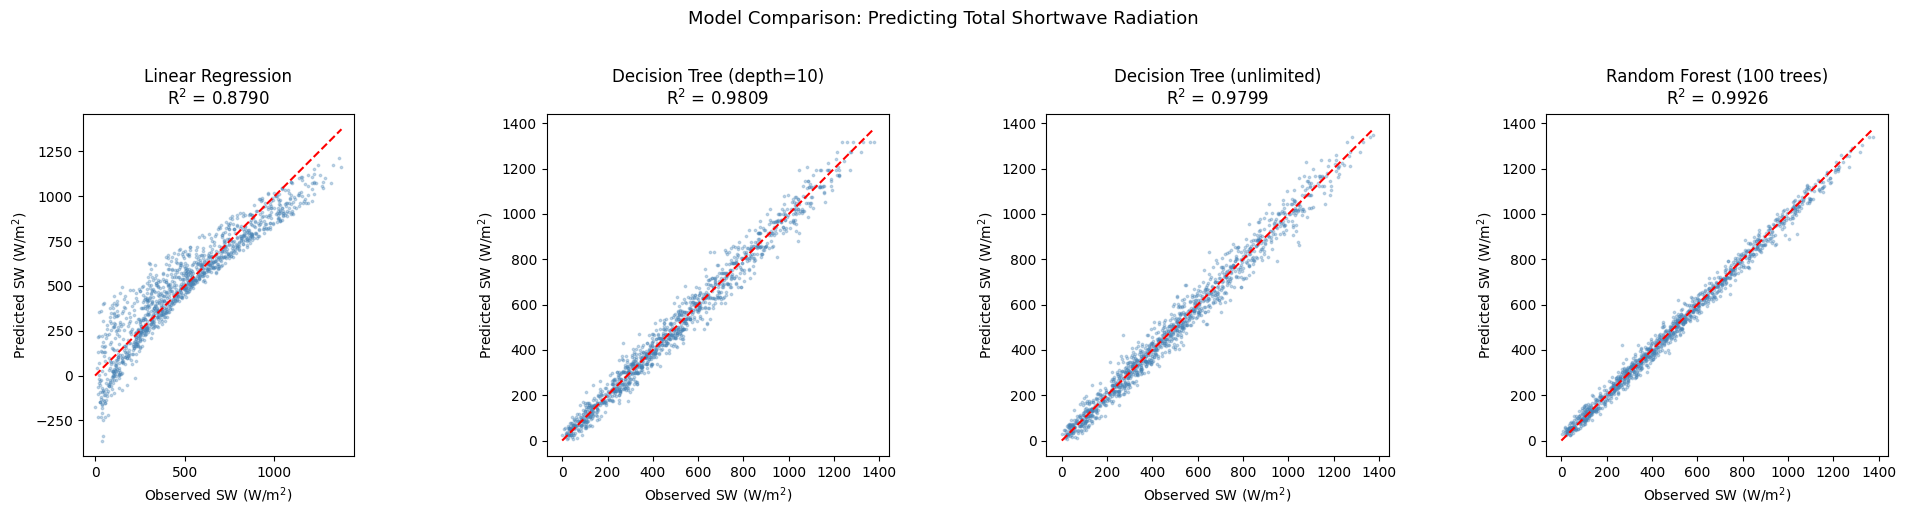

In [ ]:
# ── 1:1 plots for each model ──
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test)
    r2 = r2_score(yt_test, y_pred)

    ax.scatter(yt_test, y_pred, s=3, alpha=0.3, color='steelblue')
    ax.plot([0, yt_test.max()], [0, yt_test.max()], 'r--', linewidth=1.5)
    ax.set_xlabel('Observed SW (W/m$^2$)')
    ax.set_ylabel('Predicted SW (W/m$^2$)')
    ax.set_title(f'{name}\nR$^2$ = {r2:.4f}')
    ax.set_aspect('equal')

plt.suptitle('Model Comparison: Predicting Total Shortwave Radiation',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Key observations

- **Linear regression** captures the dominant SZA effect but cannot model the nonlinear aerosol and cloud interactions. Its 1:1 plot shows systematic scatter.
- **Decision tree (unlimited)** overfits — near-perfect training $R^2$ but noticeably lower test $R^2$.
- **Decision tree (depth=10)** trades some training fit for better generalization.
- **Random forest** achieves the best test $R^2$ — the ensemble smooths out the noise of individual trees.

The random forest's advantage is especially visible in the 1:1 plot: points cluster tightly around the diagonal with minimal scatter.


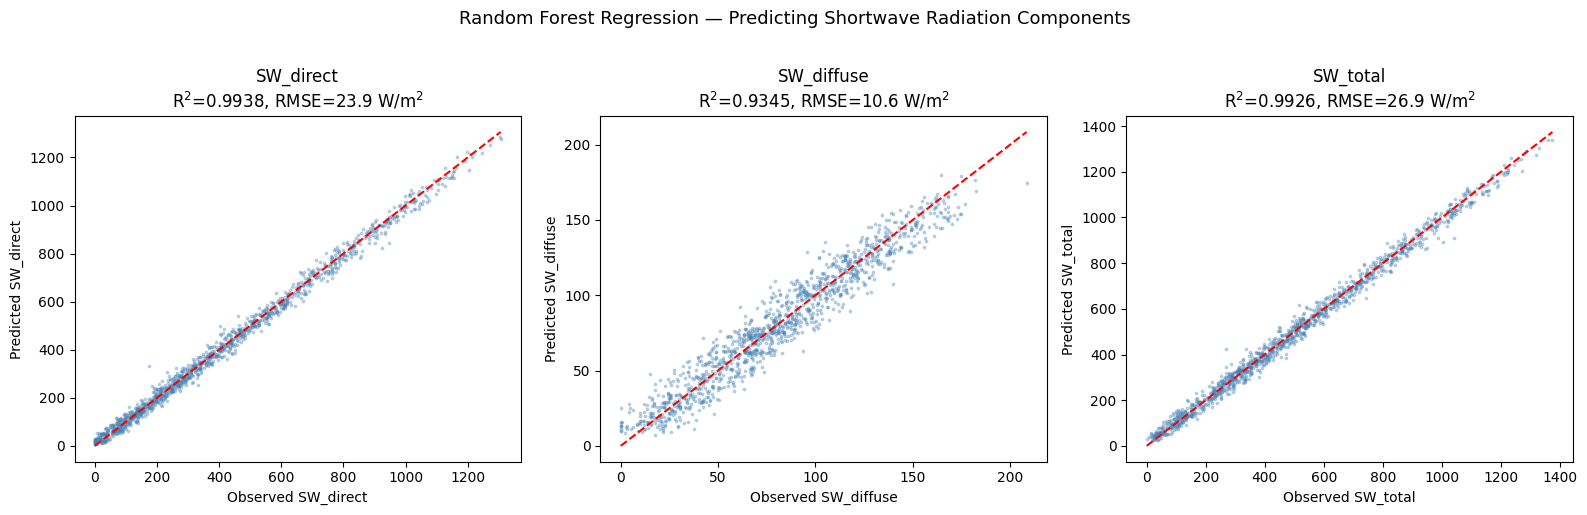

In [ ]:
# ── Predict all three targets with Random Forest ──
targets = {'SW_direct': (yd_train, yd_test),
           'SW_diffuse': (yf_train, yf_test),
           'SW_total': (yt_train, yt_test)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (target_name, (y_tr, y_te)) in zip(axes, targets.items()):
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_tr)

    y_pred = rf_model.predict(X_test)
    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    ax.scatter(y_te, y_pred, s=3, alpha=0.3, color='steelblue')
    max_val = max(y_te.max(), y_pred.max())
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5)
    ax.set_xlabel(f'Observed {target_name}')
    ax.set_ylabel(f'Predicted {target_name}')
    ax.set_title(f'{target_name}\nR$^2$={r2:.4f}, RMSE={rmse:.1f} W/m$^2$')

plt.suptitle('Random Forest Regression — Predicting Shortwave Radiation Components',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


The random forest produces excellent predictions for all three targets. **SW_direct** is easier to predict (dominated by the SZA-cosine relationship) while **SW_diffuse** is harder (more complex dependence on cloud and aerosol properties).


### Feature importance: What drives shortwave radiation?


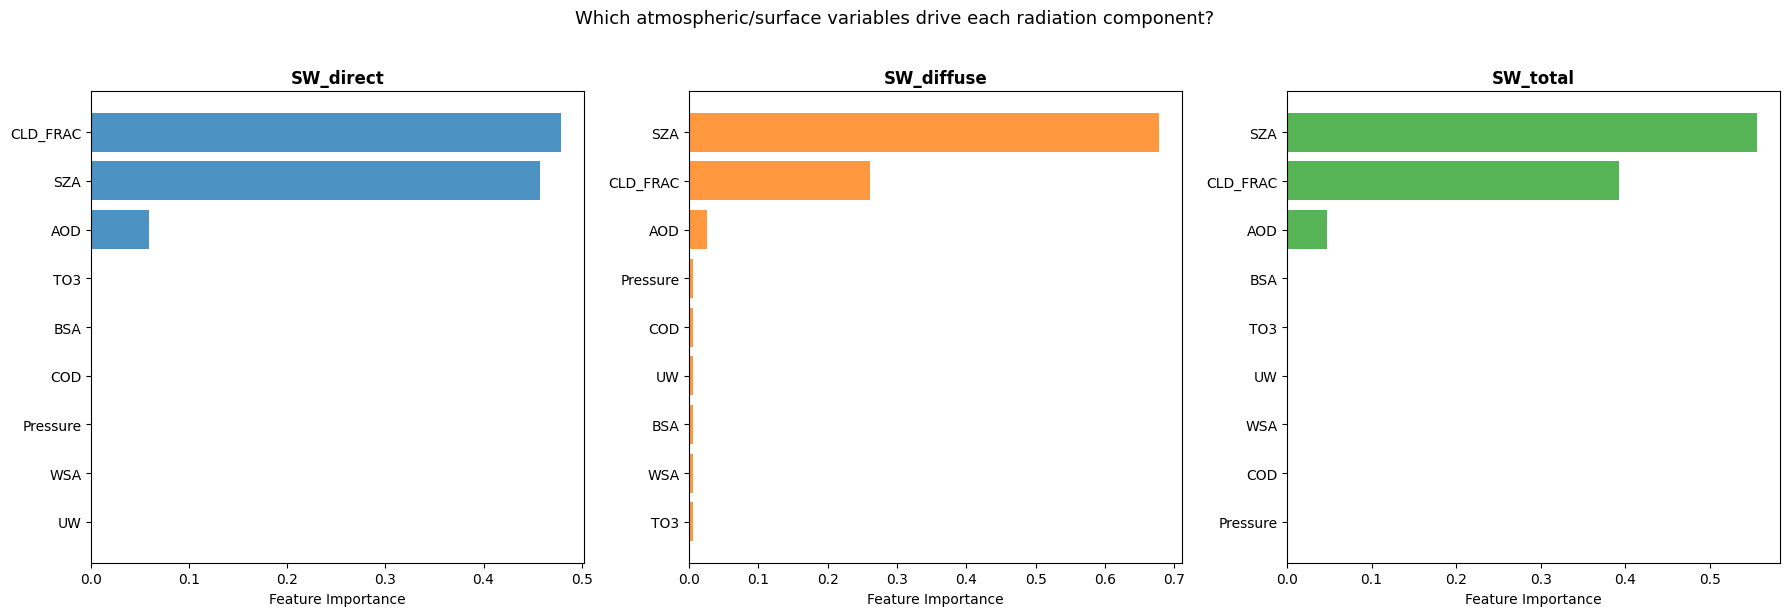

In [ ]:
# ── Feature importance for each target ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, (target_name, (y_tr, y_te)), color in zip(axes, targets.items(), colors_list):
    rf_fi = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_fi.fit(X_train, y_tr)

    imp = rf_fi.feature_importances_
    sorted_idx = np.argsort(imp)

    ax.barh(range(len(sorted_idx)), imp[sorted_idx], color=color, alpha=0.8)
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels(np.array(feature_cols)[sorted_idx])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{target_name}', fontweight='bold')

plt.suptitle('Which atmospheric/surface variables drive each radiation component?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Ecological / physical interpretation

The feature importance plots tell a physically meaningful story:

**SW_direct (direct beam radiation):**
- **SZA** dominates — the sun angle is the primary control on how much direct radiation reaches the surface (cosine law).
- **CLD_FRAC** is second — clouds block direct sunlight.
- **AOD** is third — aerosols attenuate the direct beam (Beer-Lambert law).

**SW_diffuse (diffuse radiation):**
- **SZA** still matters (controls total available radiation).
- **CLD_FRAC** and **COD** are important — clouds scatter sunlight, converting direct beam into diffuse radiation.
- **AOD** contributes — aerosols also scatter radiation.

**SW_total (sum of direct + diffuse):**
- **SZA** dominates overall.
- Both cloud and aerosol variables contribute because they redistribute radiation between direct and diffuse components.

These results are **physically consistent** with radiative transfer theory — and the random forest learned these relationships entirely from the data, without being told any physics.

> **This is a powerful use case for ML in environmental science:** building fast emulators that approximate expensive physics-based models. A random forest trained on radiative transfer model output can produce SW estimates thousands of times faster than running the full model — enabling real-time applications and integration into Earth system models.


## 11. Summary

| Concept | Key takeaway |
|---|---|
| Decision tree | Recursively splits features to create a flowchart of yes/no questions |
| Classification tree | Predicts the majority class at each leaf; splits minimize Gini impurity |
| Regression tree | Predicts the mean target value at each leaf; splits minimize variance |
| Gini impurity | Measures class mixing; 0 = pure, 0.5 = maximally mixed (binary) |
| Information gain | Decrease in impurity from a split; tree picks the split with highest gain |
| Overfitting | Unlimited trees memorize noise; control with `max_depth`, `min_samples_leaf` |
| Random forest | Ensemble of trees trained on bootstrap samples with random feature subsets |
| Bagging | Bootstrap + aggregation reduces variance without increasing bias |
| No scaling needed | Trees split on thresholds within individual features, not on distances |
| Feature importance | Sum of impurity decrease across all splits involving a feature, across all trees |
| SW radiation example | Random forest captures nonlinear atmospheric physics; SZA, CLD_FRAC, AOD are top predictors |

### Key hyperparameters

| Parameter | Decision Tree | Random Forest |
|---|---|---|
| `max_depth` | Limits tree depth (critical for preventing overfitting) | Less critical (ensemble averages out overfit) but still useful |
| `n_estimators` | n/a | Number of trees (100–500 typical; diminishing returns beyond ~200) |
| `max_features` | n/a | Features considered per split (`'sqrt'` for classification, `'auto'`/`n/3` for regression) |
| `min_samples_leaf` | Minimum samples in a leaf (prevents tiny, noisy leaves) | Same |
